In [1]:
!pip install -q unsloth scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 136.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive"

!cp -r "{DRIVE_ROOT}/llama3.1-8b-legal-clause-lora-sft" .
!cp -r "{DRIVE_ROOT}/llama3.1-8b-legal-clause-lora-dpo" .
!mkdir -p data

import os
if os.path.exists(f"{DRIVE_ROOT}/data/test.jsonl"):
    !cp "{DRIVE_ROOT}/data/test.jsonl" "{DRIVE_ROOT}/data/categories.json" data/
elif os.path.exists(f"{DRIVE_ROOT}/test.jsonl"):
    !cp "{DRIVE_ROOT}/test.jsonl" "{DRIVE_ROOT}/categories.json" data/
else:
    print("test.jsonl / categories.json not found in Drive.")
    print("Please upload them directly into the 'data' folder via the file browser "
          "(left sidebar) — they're small files, no need to zip or use Drive for these.")

!ls llama3.1-8b-legal-clause-lora-sft
!ls llama3.1-8b-legal-clause-lora-dpo
!ls data/

Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/llama3.1-8b-legal-clause-lora-dpo': No such file or directory
test.jsonl / categories.json not found in Drive.
Please upload them directly into the 'data' folder via the file browser (left sidebar) — they're small files, no need to zip or use Drive for these.
adapter_config.json	   chat_template.jinja	tokenizer_config.json
adapter_model.safetensors  README.md		tokenizer.json
ls: cannot access 'llama3.1-8b-legal-clause-lora-dpo': No such file or directory


In [4]:
# 1. Copy and unzip the DPO adapter from Drive
!cp "/content/drive/MyDrive/llama3.1-8b-legal-clause-lora-dpo.zip" .
!unzip -q llama3.1-8b-legal-clause-lora-dpo.zip
!ls llama3.1-8b-legal-clause-lora-dpo

# 2. Check if test.jsonl/categories.json landed somewhere else
!find /content -name "test.jsonl" -o -name "categories.json"

adapter_config.json	   chat_template.jinja	tokenizer_config.json
adapter_model.safetensors  README.md		tokenizer.json


In [9]:
!cp "/content/drive/MyDrive/test.jsonl" data/
!ls data/

test.jsonl


In [10]:
!cp "/content/drive/MyDrive/categories.json" data/
!ls data/

categories.json  test.jsonl


In [11]:
import json

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

test_records = load_jsonl("data/test.jsonl")

with open("data/categories.json") as f:
    cat_config = json.load(f)

CATEGORIES = cat_config["categories"]
SYSTEM_PROMPT = cat_config["system_prompt"]

# Expanded edge cases: 3 per category, 30 total. Each is deliberately tricky —
# containing keywords from OTHER categories, or phrased ambiguously.
EDGE_CASES_RAW = [
    # Governing Laws
    ("This Agreement, and any dispute arising hereunder, shall be governed by "
     "the internal laws of New York, without regard to conflicts of law principles.", "Governing Laws"),
    ("Any action to enforce this Agreement upon termination shall be brought in "
     "accordance with the laws of the State of Texas.", "Governing Laws"),
    ("The interpretation and validity of this Agreement, including any amendments "
     "hereto, shall be determined under Delaware law.", "Governing Laws"),

    # Terminations
    ("This Agreement may be terminated by either party for convenience upon "
     "sixty days' written notice.", "Terminations"),
    ("Upon a material breach that remains uncured for 30 days following notice, "
     "the non-breaching party may end this Agreement immediately.", "Terminations"),
    ("The Company reserves the right to end this engagement at any time, with "
     "or without cause, subject to the notice requirements herein.", "Terminations"),

    # Confidentiality
    ("The Receiving Party shall not disclose the Disclosing Party's trade "
     "secrets to any third party without prior written consent.", "Confidentiality"),
    ("All confidential information shall be returned or destroyed upon "
     "termination of this Agreement.", "Confidentiality"),  # mentions "termination" but is about handling confidential info
    ("Each party agrees to protect the other's proprietary business information "
     "with the same degree of care it uses for its own confidential data.", "Confidentiality"),

    # Indemnifications
    ("The Company shall defend, indemnify, and hold the Executive harmless "
     "against any third-party claims arising from good-faith actions.", "Indemnifications"),
    ("Borrower shall indemnify and hold harmless the Lender against any losses, "
     "claims, damages, or liabilities arising out of this Agreement.", "Indemnifications"),
    ("Each party shall reimburse and hold the other harmless for losses "
     "resulting from a breach of the representations herein.", "Indemnifications"),

    # Assignments
    ("Neither party shall assign its rights hereunder without the prior "
     "written consent of the other party.", "Assignments"),
    ("This Agreement shall be binding upon and inure to the benefit of the "
     "parties' permitted successors and assigns.", "Assignments"),  # tricky: sounds like binding-effect/successors, but core act is assignment permission
    ("Any purported assignment in violation of this Section shall be null "
     "and void ab initio.", "Assignments"),

    # Notices
    ("Notices of assignment shall be governed by the laws of Delaware and "
     "delivered in writing to the addresses listed below.", "Notices"),  # mentions assignment + governing law, but core act is delivering notices
    ("All notices required under this Agreement shall be deemed given upon "
     "personal delivery or three days after mailing.", "Notices"),
    ("Any notice of termination must be delivered in writing to the address "
     "set forth in Schedule A.", "Notices"),  # mentions "termination" but is about notice delivery mechanics

    # Severability
    ("Should any clause be found unenforceable, the balance of the Agreement "
     "shall continue in full force and effect.", "Severability"),
    ("If a court of competent jurisdiction holds any provision invalid, the "
     "parties shall negotiate a replacement provision achieving similar intent.", "Severability"),
    ("The invalidity of any part of this Agreement shall not affect the "
     "validity of the remaining provisions.", "Severability"),

    # Counterparts
    ("The parties may execute this instrument in any number of counterparts, "
     "each of which shall be deemed an original.", "Counterparts"),
    ("This Agreement may be signed in multiple counterparts, including by "
     "electronic or facsimile signature, which together form one document.", "Counterparts"),
    ("Delivery of an executed counterpart by email shall be as effective as "
     "delivery of an originally signed copy.", "Counterparts"),

    # Amendments
    ("No amendment to this Agreement shall be effective unless in writing "
     "and signed by both parties.", "Amendments"),
    ("This Agreement may only be modified by a written instrument executed "
     "by authorized representatives of both parties.", "Amendments"),
    ("Any waiver or modification of these terms must be agreed to in writing; "
     "no oral modification shall be binding.", "Amendments"),

    # Survival
    ("The provisions of Section 8 shall survive the expiration or "
     "termination of this Agreement and remain in full force.", "Survival"),  # mentions "termination" but is about what continues after
    ("Obligations relating to confidentiality and indemnification shall "
     "survive termination of this Agreement for a period of two years.", "Survival"),
    ("Notwithstanding anything to the contrary, the obligations of Sellers "
     "under this Article shall survive until the expiration of the "
     "applicable statute of limitations.", "Survival"),
]

def to_chat_record(clause_text, category):
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Clause:\n{clause_text}"},
            {"role": "assistant", "content": category},
        ]
    }

edge_records = [to_chat_record(t, c) for t, c in EDGE_CASES_RAW]

print(f"Test set: {len(test_records)} clauses")
print(f"Edge cases: {len(edge_records)} clauses (expanded from 12 to 30, 3 per category)")
print(f"Categories: {CATEGORIES}")

Test set: 150 clauses
Edge cases: 30 clauses (expanded from 12 to 30, 3 per category)
Categories: ['Governing Laws', 'Terminations', 'Confidentiality', 'Indemnifications', 'Assignments', 'Notices', 'Severability', 'Counterparts', 'Amendments', 'Survival']


In [12]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
import torch

MAX_SEQ_LENGTH = 1024
BASE_MODEL_NAME = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"

def load_model_variant(adapter_path=None):
    """adapter_path=None loads the plain base model. Otherwise loads base + that adapter."""
    model_name = adapter_path if adapter_path else BASE_MODEL_NAME
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def classify_clause(model, tokenizer, system_prompt, clause_text, max_new_tokens=12):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Clause:\n{clause_text}"},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.0,          # deterministic — no sampling, for fair evaluation
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs.shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

def clean_prediction(raw_text: str, categories: list) -> str:
    """Maps the model's raw text output to the closest valid category, or 'INVALID' if
    no category name appears in the output at all."""
    raw_lower = raw_text.lower()
    for cat in categories:
        if cat.lower() in raw_lower:
            return cat
    return "INVALID"

print("Helper functions ready.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_pil_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.auto.image_processing_auto`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_beit`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_pil_beit`. R

🦥 Unsloth Zoo will now patch everything to make training faster!
Helper functions ready.


In [13]:
base_model, base_tokenizer = load_model_variant(adapter_path=None)

base_predictions = []
for i, rec in enumerate(test_records):
    clause_text = rec["messages"][1]["content"].replace("Clause:\n", "", 1)
    true_label = rec["messages"][2]["content"]
    raw_output = classify_clause(base_model, base_tokenizer, SYSTEM_PROMPT, clause_text)
    pred = clean_prediction(raw_output, CATEGORIES)
    base_predictions.append({"clause": clause_text, "true": true_label, "raw": raw_output, "pred": pred})
    if (i + 1) % 25 == 0:
        print(f"  base model: {i+1}/{len(test_records)} done")

print("Base model evaluation complete.")

# free GPU memory before loading the next model
del base_model
torch.cuda.empty_cache()

==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_

  base model: 25/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  base model: 100/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  base model: 125/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  base model: 150/150 done
Base model evaluation complete.


In [14]:
sft_model, sft_tokenizer = load_model_variant(adapter_path="llama3.1-8b-legal-clause-lora-sft")

sft_predictions = []
for i, rec in enumerate(test_records):
    clause_text = rec["messages"][1]["content"].replace("Clause:\n", "", 1)
    true_label = rec["messages"][2]["content"]
    raw_output = classify_clause(sft_model, sft_tokenizer, SYSTEM_PROMPT, clause_text)
    pred = clean_prediction(raw_output, CATEGORIES)
    sft_predictions.append({"clause": clause_text, "true": true_label, "raw": raw_output, "pred": pred})
    if (i + 1) % 25 == 0:
        print(f"  SFT model: {i+1}/{len(test_records)} done")

print("SFT model evaluation complete.")

del sft_model
torch.cuda.empty_cache()


==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load llama3.1-8b-legal-clause-lora-sft as a legacy tokenizer.
Unsloth 2026.7.2 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be re

  SFT model: 25/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  SFT model: 100/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  SFT model: 125/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  SFT model: 150/150 done
SFT model evaluation complete.


In [15]:
dpo_model, dpo_tokenizer = load_model_variant(adapter_path="llama3.1-8b-legal-clause-lora-dpo")

dpo_predictions = []
for i, rec in enumerate(test_records):
    clause_text = rec["messages"][1]["content"].replace("Clause:\n", "", 1)
    true_label = rec["messages"][2]["content"]
    raw_output = classify_clause(dpo_model, dpo_tokenizer, SYSTEM_PROMPT, clause_text)
    pred = clean_prediction(raw_output, CATEGORIES)
    dpo_predictions.append({"clause": clause_text, "true": true_label, "raw": raw_output, "pred": pred})
    if (i + 1) % 25 == 0:
        print(f"  DPO model: {i+1}/{len(test_records)} done")

print("DPO model evaluation complete.")

==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load llama3.1-8b-legal-clause-lora-dpo as a legacy tokenizer.
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more informati

  DPO model: 25/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  DPO model: 100/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  DPO model: 125/150 done


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  DPO model: 150/150 done
DPO model evaluation complete.


In [16]:
from sklearn.metrics import accuracy_score, classification_report

def get_accuracy(predictions):
    y_true = [p["true"] for p in predictions]
    y_pred = [p["pred"] for p in predictions]
    return accuracy_score(y_true, y_pred), y_true, y_pred

base_acc, base_true, base_pred = get_accuracy(base_predictions)
sft_acc, sft_true, sft_pred = get_accuracy(sft_predictions)
dpo_acc, dpo_true, dpo_pred = get_accuracy(dpo_predictions)

print(f"BASE model accuracy: {base_acc*100:.1f}%")
print(f"SFT  model accuracy: {sft_acc*100:.1f}%")
print(f"DPO  model accuracy: {dpo_acc*100:.1f}%")

print("\n--- DPO model classification report ---")
print(classification_report(dpo_true, dpo_pred, zero_division=0))

BASE model accuracy: 94.0%
SFT  model accuracy: 97.3%
DPO  model accuracy: 96.7%

--- DPO model classification report ---
                  precision    recall  f1-score   support

      Amendments       1.00      1.00      1.00        15
     Assignments       1.00      0.87      0.93        15
 Confidentiality       1.00      1.00      1.00        15
    Counterparts       1.00      1.00      1.00        15
  Governing Laws       1.00      1.00      1.00        15
         INVALID       0.00      0.00      0.00         0
Indemnifications       1.00      1.00      1.00        15
         Notices       1.00      1.00      1.00        15
    Severability       1.00      0.93      0.97        15
        Survival       0.93      0.93      0.93        15
    Terminations       0.82      0.93      0.88        15

        accuracy                           0.97       150
       macro avg       0.89      0.88      0.88       150
    weighted avg       0.98      0.97      0.97       150



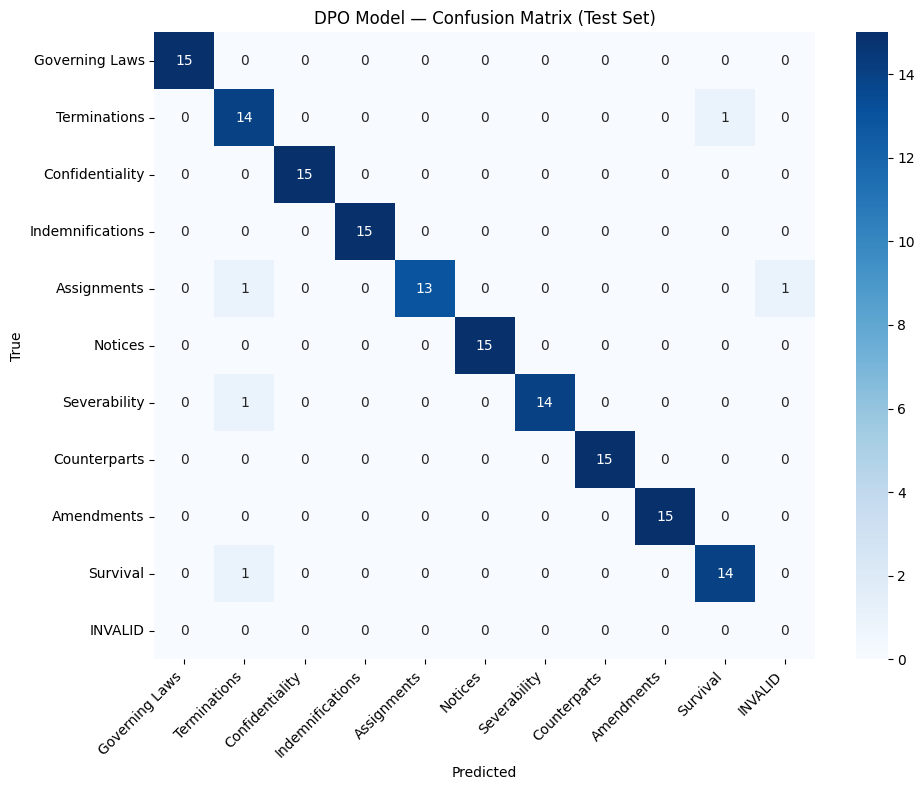

Saved confusion_matrix_dpo.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_for_matrix = CATEGORIES + (["INVALID"] if "INVALID" in dpo_pred else [])
cm = confusion_matrix(dpo_true, dpo_pred, labels=labels_for_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_for_matrix, yticklabels=labels_for_matrix)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DPO Model — Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_dpo.png", dpi=150)
plt.show()

print("Saved confusion_matrix_dpo.png")

In [18]:
def evaluate_on_edge_cases(model, tokenizer, label):
    results = []
    correct = 0
    for rec in edge_records:
        clause_text = rec["messages"][1]["content"].replace("Clause:\n", "", 1)
        true_label = rec["messages"][2]["content"]
        raw_output = classify_clause(model, tokenizer, SYSTEM_PROMPT, clause_text)
        pred = clean_prediction(raw_output, CATEGORIES)
        is_correct = (pred == true_label)
        correct += is_correct
        results.append({"clause": clause_text[:80] + "...", "true": true_label,
                         "pred": pred, "correct": is_correct})
    print(f"\n{label} edge-case accuracy: {correct}/{len(edge_records)}")
    for r in results:
        mark = "✓" if r["correct"] else "✗"
        print(f"  {mark} true={r['true']:<18} pred={r['pred']:<18} | {r['clause']}")
    return results

In [19]:
dpo_edge_results = evaluate_on_edge_cases(dpo_model, dpo_tokenizer, "DPO")


Both `max_new_tokens` (=12) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1


DPO edge-case accuracy: 30/30
  ✓ true=Governing Laws     pred=Governing Laws     | This Agreement, and any dispute arising hereunder, shall be governed by the inte...
  ✓ true=Governing Laws     pred=Governing Laws     | Any action to enforce this Agreement upon termination shall be brought in accord...
  ✓ true=Governing Laws     pred=Governing Laws     | The interpretation and validity of this Agreement, including any amendments here...
  ✓ true=Terminations       pred=Terminations       | This Agreement may be terminated by either party for convenience upon sixty days...
  ✓ true=Terminations       pred=Terminations       | Upon a material breach that remains uncured for 30 days following notice, the no...
  ✓ true=Terminations       pred=Terminations       | The Company reserves the right to end this engagement at any time, with or witho...
  ✓ true=Confidentiality    pred=Confidentiality    | The Receiving Party shall not disclose the Disclosing Party's trade secrets to a...
  ✓

In [20]:
GENERAL_PROMPTS = [
    "What is the capital of France?",
    "Explain in one sentence why the sky is blue.",
    "What is 15 multiplied by 8?",
    "Write a short, friendly greeting for a customer service chatbot.",
]

def ask_general_question(model, tokenizer, question):
    messages = [{"role": "user", "content": question}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs, max_new_tokens=100, temperature=0.0, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs.shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

print("--- DPO model's answers to general questions (forgetting check) ---\n")
for q in GENERAL_PROMPTS:
    answer = ask_general_question(dpo_model, dpo_tokenizer, q)
    print(f"Q: {q}\nA: {answer}\n")

del dpo_model
torch.cuda.empty_cache()

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- DPO model's answers to general questions (forgetting check) ---



Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What is the capital of France?
A: The capital of France is Paris.



Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Explain in one sentence why the sky is blue.
A: The sky appears blue because of a phenomenon called Rayleigh scattering, where sunlight interacts with tiny molecules of gases in the atmosphere, scattering shorter (blue) wavelengths more than longer (red) wavelengths.



Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What is 15 multiplied by 8?
A: 15 multiplied by 8 is 120.

Q: Write a short, friendly greeting for a customer service chatbot.
A: Hello! How can I assist you today?



In [21]:
regressions = []
improvements = []
for base_p, dpo_p in zip(base_predictions, dpo_predictions):
    assert base_p["clause"] == dpo_p["clause"], "predictions are misaligned!"
    base_correct = (base_p["pred"] == base_p["true"])
    dpo_correct = (dpo_p["pred"] == dpo_p["true"])
    if base_correct and not dpo_correct:
        regressions.append({"clause": base_p["clause"][:100] + "...", "true": base_p["true"],
                             "base_pred": base_p["pred"], "dpo_pred": dpo_p["pred"]})
    elif not base_correct and dpo_correct:
        improvements.append({"clause": base_p["clause"][:100] + "...", "true": base_p["true"],
                              "base_pred": base_p["pred"], "dpo_pred": dpo_p["pred"]})

print(f"Regressions (base correct, DPO wrong): {len(regressions)}")
for r in regressions:
    print(f"  true={r['true']:<18} base_pred={r['base_pred']:<18} dpo_pred={r['dpo_pred']:<18} | {r['clause']}")

print(f"\nImprovements (base wrong, DPO correct): {len(improvements)}")
for r in improvements[:10]:   # show first 10 if there are many
    print(f"  true={r['true']:<18} base_pred={r['base_pred']:<18} dpo_pred={r['dpo_pred']:<18} | {r['clause']}")
if len(improvements) > 10:
    print(f"  ... and {len(improvements) - 10} more")

Regressions (base correct, DPO wrong): 0

Improvements (base wrong, DPO correct): 4
  true=Amendments         base_pred=Governing Laws     dpo_pred=Amendments         | (defined below), the “ Extended Agreement ”), by and among the Borrower, the Banks listed on the sig...
  true=Severability       base_pred=Governing Laws     dpo_pred=Severability       | Any provision of this Agreement that is prohibited or unenforceable in any jurisdiction will be inef...
  true=Amendments         base_pred=Terminations       dpo_pred=Amendments         | This Agreement shall not be amended, modified or supplemented at any time or terminated without the ...
  true=Confidentiality    base_pred=Governing Laws     dpo_pred=Confidentiality    | In the event of the consummation or public announcement of any Placement, Rodman shall have the righ...


In [23]:
!pip install -q groq

import os
from groq import Groq

os.environ["GROQ_API_KEY"] = input("Paste your API key").strip()
groq_client = Groq()

JUDGE_PROMPT_TEMPLATE = """You are evaluating a legal clause classification task.

Clause: {clause}

Correct category: {true_label}

Model A's answer: {base_pred}
Model B's answer: {dpo_pred}

For EACH model (A and B), score its answer from 1-5 (5 = exactly correct and cleanly
formatted, 1 = completely wrong or unusable), and give a one-sentence reason.

Respond ONLY in this exact format, nothing else:
A_SCORE: <number>
A_REASON: <one sentence>
B_SCORE: <number>
B_REASON: <one sentence>
"""

def judge_pair(clause, true_label, base_pred, dpo_pred):
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        clause=clause[:500], true_label=true_label, base_pred=base_pred, dpo_pred=dpo_pred
    )
    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",   # Groq deprecated llama-3.3-70b-versatile in June 2026;
                                        # this is their current recommended general-purpose model
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=150,
    )
    return response.choices[0].message.content.strip()

# Judge a random sample of 20 test clauses (judging all 150 costs more API calls than
# needed for a representative quality signal)
import random
random.seed(42)
judge_sample = random.sample(list(zip(base_predictions, dpo_predictions)), 20)

judge_results = []
for i, (base_p, dpo_p) in enumerate(judge_sample):
    verdict_text = judge_pair(base_p["clause"], base_p["true"], base_p["pred"], dpo_p["pred"])
    judge_results.append({"clause": base_p["clause"][:80] + "...", "true": base_p["true"],
                           "base_pred": base_p["pred"], "dpo_pred": dpo_p["pred"],
                           "verdict": verdict_text})
    if (i + 1) % 5 == 0:
        print(f"  judged {i+1}/{len(judge_sample)}...")

print("\n--- Sample judge verdicts ---")
for r in judge_results[:5]:
    print(f"\nClause: {r['clause']}")
    print(f"True: {r['true']} | Base: {r['base_pred']} | DPO: {r['dpo_pred']}")
    print(r["verdict"])

Paste your API keygsk_KWU8kbpBHC335TveDr1KWGdyb3FYBa72HvqTbCV2Lf0JEhSfEMiq
  judged 5/20...
  judged 10/20...
  judged 15/20...
  judged 20/20...

--- Sample judge verdicts ---

Clause: This Agreement may not be assigned by the Executive. Neither the Executive, his ...
True: Assignments | Base: Assignments | DPO: Assignments
A_SCORE: 5
A_REASON: The model correctly identified the clause as belonging to the Assignments category.
B_SCORE: 5
B_REASON: The model also correctly classified

Clause: The provisions contained in this Section 10 shall survive the Closing or earlier...
True: Survival | Base: Survival | DPO: Survival
A_SCORE: 5
A_REASON: The answer exactly matches the correct category and is properly formatted.
B_SCORE: 5
B_REASON: The answer correctly identifies the category and follows the required format.

Clause: All notices and other communications provided for hereunder shall, unless otherw...
True: Notices | Base: Notices | DPO: Notices
A_SCORE: 5
A_REASON: The model correc

In [25]:
results_summary = {
    "base_accuracy": base_acc,
    "sft_accuracy": sft_acc,
    "dpo_accuracy": dpo_acc,
    "dpo_edge_case_correct": sum(r["correct"] for r in dpo_edge_results),
    "dpo_edge_case_total": len(dpo_edge_results),
    "regressions_count": len(regressions),
    "improvements_count": len(improvements),
}

with open("evaluation_results.json", "w") as f:
    json.dump({
        "summary": results_summary,
        "base_predictions": base_predictions,
        "sft_predictions": sft_predictions,
        "dpo_predictions": dpo_predictions,
        "dpo_edge_case_results": dpo_edge_results,
        "regressions": regressions,
        "improvements": improvements,
        "judge_results": judge_results,
    }, f, indent=2)

print("Saved evaluation_results.json")
print("\nSUMMARY:")
print(f"  Base accuracy: {base_acc*100:.1f}%")
print(f"  SFT  accuracy: {sft_acc*100:.1f}%")
print(f"  DPO  accuracy: {dpo_acc*100:.1f}%")
print(f"  DPO edge cases: {results_summary['dpo_edge_case_correct']}/{results_summary['dpo_edge_case_total']}")
print(f"  Regressions: {results_summary['regressions_count']} | Improvements: {results_summary['improvements_count']}")
print("\nStep 04 complete. Ready for Step 05 (inference pipeline / demo).")

Saved evaluation_results.json

SUMMARY:
  Base accuracy: 94.0%
  SFT  accuracy: 97.3%
  DPO  accuracy: 96.7%
  DPO edge cases: 30/30
  Regressions: 0 | Improvements: 4

Step 04 complete. Ready for Step 05 (inference pipeline / demo).
